# User Demographics EDA
**Name:** Marwa Mohamed Elhussieny

**ID:** 15

**Data source:** https://dummyjson.com/users?limit=100

## 0. Imports & Setup

In [1]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs('plots', exist_ok=True)

sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.2)
sns.set_palette('Set2')

## 1. Load Data

In [2]:
url = 'https://dummyjson.com/users?limit=100'
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data['users'])
df.head()

,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,company.address.city,company.address.state,company.address.stateCode,company.address.postalCode,company.address.coordinates.lat,company.address.coordinates.lng,company.address.country,crypto.coin,crypto.wallet,crypto.network
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,San Francisco,Wisconsin,WI,37657,71.814525,-161.150263,United States,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20)
1,2,Michael,Williams,,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,Los Angeles,New Hampshire,NH,73442,79.098326,-119.624845,United States,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20)
2,3,Sophia,Brown,,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,Dallas,Nevada,NV,88511,20.086743,-34.577107,United States,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20)
3,4,James,Davis,,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,Fort Worth,Pennsylvania,PA,27768,54.911930,-79.498328,United States,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20)
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,San Antonio,Idaho,ID,21965,44.346545,-26.944701,United States,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20)


## 2. Basic Data Exploration

In [3]:
print('Shape:', df.shape)

Shape: (100, 52)


In [4]:
print('Columns:\n', df.columns.tolist())

Columns:
 ['id', 'firstName', 'lastName', 'maidenName', 'age', 'gender', 'email', 'phone', 'username', 'password', 'birthDate', 'image', 'bloodGroup', 'height', 'weight', 'eyeColor', 'ip', 'macAddress', 'university', 'ein', 'ssn', 'userAgent', 'role', 'hair.color', 'hair.type', 'address.address', 'address.city', 'address.state', 'address.stateCode', 'address.postalCode', 'address.coordinates.lat', 'address.coordinates.lng', 'address.country', 'bank.cardExpire', 'bank.cardNumber', 'bank.cardType', 'bank.currency', 'bank.iban', 'company.department', 'company.name', 'company.title', 'company.address.address', 'company.address.city', 'company.address.state', 'company.address.stateCode', 'company.address.postalCode', 'company.address.coordinates.lat', 'company.address.coordinates.lng', 'company.address.country', 'crypto.coin', 'crypto.wallet', 'crypto.network']


In [5]:
print('Data types:\n')
df.dtypes

Data types:



,0
id,int64
firstName,object
lastName,object
maidenName,object
age,int64
gender,object
email,object
phone,object
username,object
password,object


In [6]:
print('Missing values per column:')
df.isnull().sum()

Missing values per column:


,0
id,0
firstName,0
lastName,0
maidenName,0
age,0
gender,0
email,0
phone,0
username,0
password,0


In [7]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [8]:
df.describe()

,id,age,height,weight,address.coordinates.lat,address.coordinates.lng,company.address.coordinates.lat,company.address.coordinates.lng
count,100.000000,100.000000,100.000000,100.0000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,31.700000,176.392500,75.0431,0.304661,-8.426883,3.300877,-10.039483
std,29.011492,4.132893,13.838342,14.0146,52.833371,105.246649,51.892119,102.017108
min,1.000000,23.000000,150.250000,50.1000,-87.184494,-176.861979,-86.557025,-169.602231
25%,25.750000,28.750000,166.700000,63.0075,-46.076624,-87.475943,-47.014297,-91.900357
50%,50.500000,31.000000,178.320000,75.4600,3.090987,-27.686222,11.113367,-12.890487
75%,75.250000,34.000000,187.617500,87.5175,42.178338,81.048713,45.542705,83.312120
max,100.000000,46.000000,199.620000,98.7700,89.781211,179.922909,89.270633,178.506028


In [9]:
for col in ['gender', 'bloodGroup', 'eyeColor', 'role', 'address.country']:
    if col in df.columns:
        print(f'--- {col} ---')
        print(df[col].value_counts(), '\n')

--- gender ---
gender
female    52
male      48
Name: count, dtype: int64 

--- bloodGroup ---
bloodGroup
O-     19
A+     15
AB-    13
AB+    13
B+     12
B-     10
O+     10
A-      8
Name: count, dtype: int64 

--- eyeColor ---
eyeColor
Brown     18
Hazel     16
Gray      14
Red       12
Blue      12
Green     11
Amber     10
Violet     7
Name: count, dtype: int64 

--- role ---
role
user         85
moderator    10
admin         5
Name: count, dtype: int64 

--- address.country ---
address.country
United States    100
Name: count, dtype: int64 



## 3. Data Cleaning

In [10]:
if 'address.country' not in df.columns:
    df['address.country'] = df['address'].apply(
        lambda x: x.get('country') if isinstance(x, dict) else None
    )

if 'address.city' not in df.columns:
    df['address.city'] = df['address'].apply(
        lambda x: x.get('city') if isinstance(x, dict) else None
    )

for col in ['age', 'height', 'weight']:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

print('Missing values after cleaning:')
df[['age', 'height', 'weight']].isnull().sum()

Missing values after cleaning:


/tmp/ipykernel_190/3542362076.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


,0
age,0
height,0
weight,0


## 4. Analysis

In [11]:
avg_age = df['age'].mean()
print(f'Average age: {avg_age:.1f} years')

Average age: 31.7 years


In [12]:
avg_age_gender = df.groupby('gender')['age'].mean()
print(avg_age_gender)

gender
female    29.730769
male      33.833333
Name: age, dtype: float64


In [13]:
gender_counts = df['gender'].value_counts()
print(gender_counts)

gender
female    52
male      48
Name: count, dtype: int64


In [14]:
top10_cities = df['address.city'].value_counts().head(10)
print(top10_cities)

address.city
Phoenix         9
Dallas          8
Columbus        8
Jacksonville    8
Chicago         6
San Diego       6
Seattle         5
Charlotte       5
Los Angeles     5
Denver          5
Name: count, dtype: int64


In [15]:
avg_height = df['height'].mean()
avg_weight = df['weight'].mean()
print(f'Average height: {avg_height:.1f} cm')
print(f'Average weight: {avg_weight:.1f} kg')

Average height: 176.4 cm
Average weight: 75.0 kg


In [16]:
corr_age_height = df['age'].corr(df['height'])
corr_age_weight = df['age'].corr(df['weight'])
print(f'Age vs Height: {corr_age_height:.3f}')
print(f'Age vs Weight: {corr_age_weight:.3f}')

Age vs Height: -0.102
Age vs Weight: -0.076


## 5. Visualizations

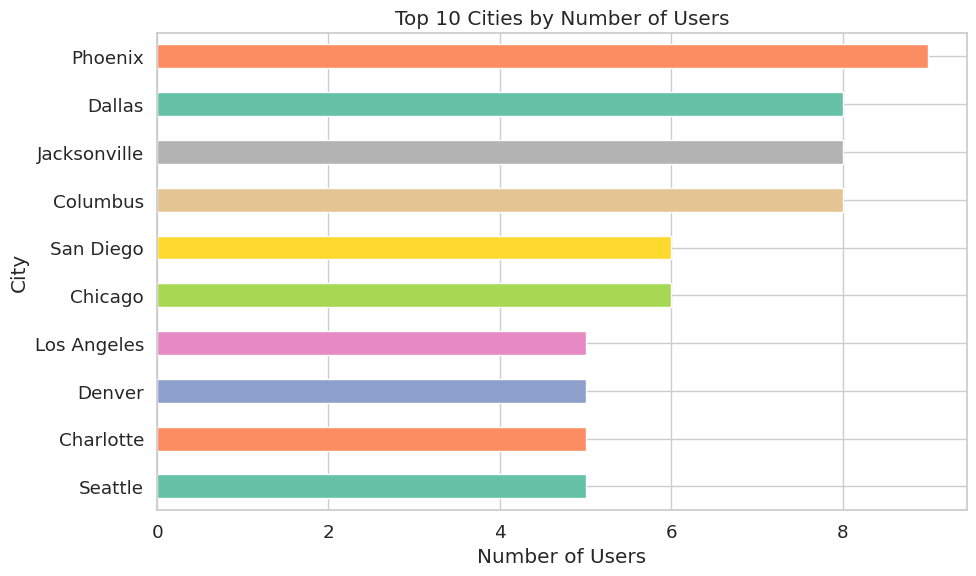

In [17]:
plt.figure(figsize=(10, 6))
top10_cities.sort_values().plot(kind='barh', color=sns.color_palette('Set2', 10))
plt.title('Top 10 Cities by Number of Users')
plt.xlabel('Number of Users')
plt.ylabel('City')
plt.tight_layout()
plt.savefig('plots/plot1_top10_cities.png', dpi=150)
plt.show()

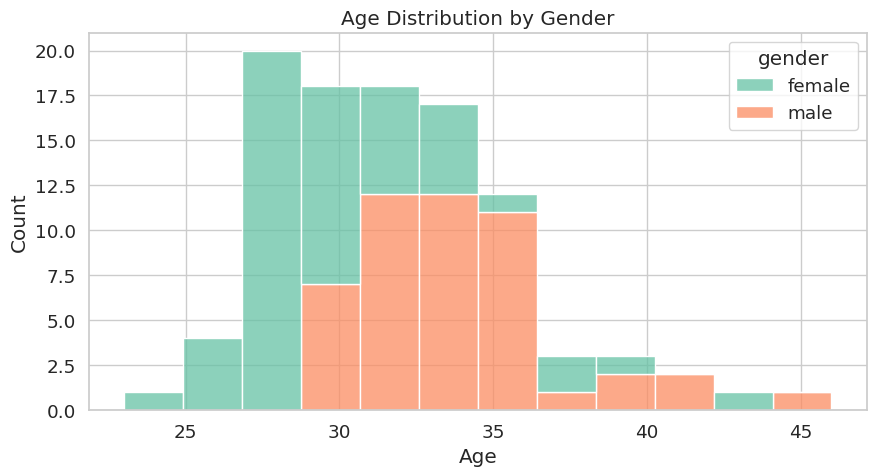

In [18]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='age', hue='gender', bins=12, multiple='stack')
plt.title('Age Distribution by Gender')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/plot2_age_distribution.png', dpi=150)
plt.show()

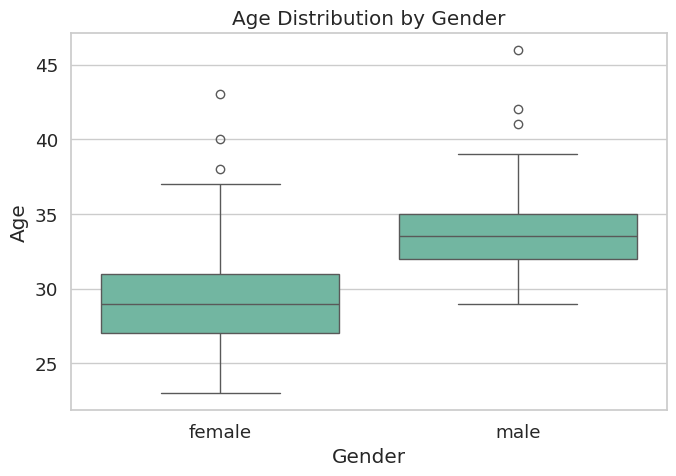

In [19]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='gender', y='age', data=df)
plt.title('Age Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.tight_layout()
plt.savefig('plots/plot3_age_boxplot.png', dpi=150)
plt.show()

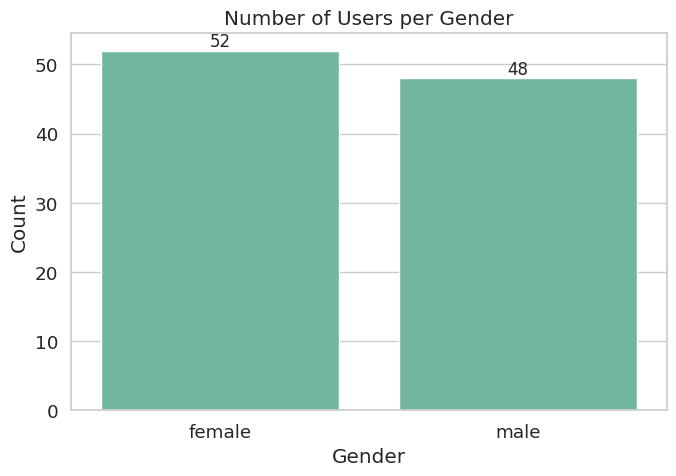

In [20]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='gender', data=df)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.title('Number of Users per Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/plot4_gender_count.png', dpi=150)
plt.show()

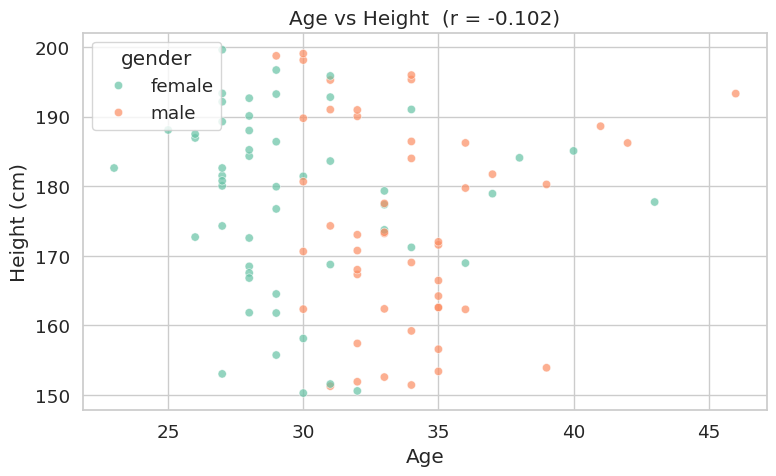

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='height', hue='gender', data=df, alpha=0.7)
plt.title(f'Age vs Height  (r = {corr_age_height:.3f})')
plt.xlabel('Age')
plt.ylabel('Height (cm)')
plt.tight_layout()
plt.savefig('plots/plot5_age_vs_height.png', dpi=150)
plt.show()

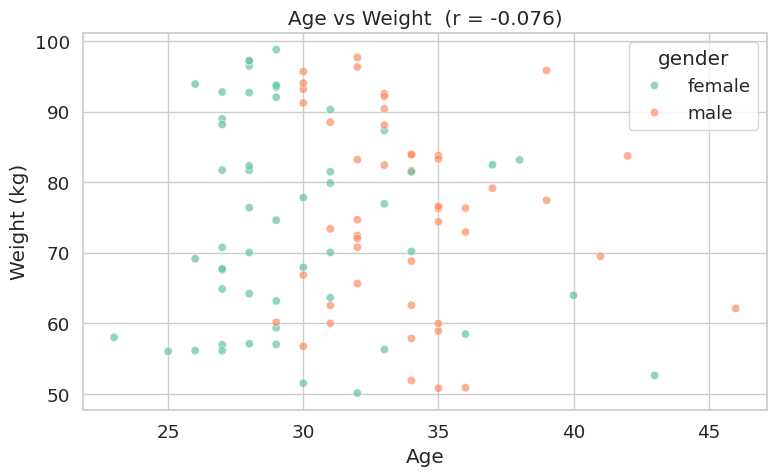

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='weight', hue='gender', data=df, alpha=0.7)
plt.title(f'Age vs Weight  (r = {corr_age_weight:.3f})')
plt.xlabel('Age')
plt.ylabel('Weight (kg)')
plt.tight_layout()
plt.savefig('plots/plot6_age_vs_weight.png', dpi=150)
plt.show()

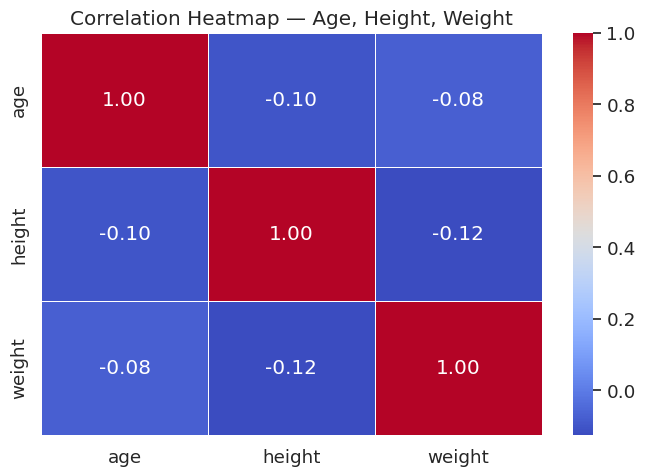

In [23]:
plt.figure(figsize=(7, 5))
numeric_cols = df[['age', 'height', 'weight']].corr()
sns.heatmap(numeric_cols, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Age, Height, Weight')
plt.tight_layout()
plt.savefig('plots/plot7_correlation_heatmap.png', dpi=150)
plt.show()